In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\loges\Downloads\swiggy (1).csv")
df.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


# Data understanding and Cleaning

In [2]:
#Let's check the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            148541 non-null  int64 
 1   name          148455 non-null  object
 2   city          148541 non-null  object
 3   rating        148455 non-null  object
 4   rating_count  148455 non-null  object
 5   cost          148410 non-null  object
 6   cuisine       148442 non-null  object
 7   lic_no        148312 non-null  object
 8   link          148541 non-null  object
 9   address       148455 non-null  object
 10  menu          148541 non-null  object
dtypes: int64(1), object(10)
memory usage: 12.5+ MB


In [3]:
#Let us keep only the columns that we need 
df.drop(columns=['id','lic_no','link','address','menu'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   name          148455 non-null  object
 1   city          148541 non-null  object
 2   rating        148455 non-null  object
 3   rating_count  148455 non-null  object
 4   cost          148410 non-null  object
 5   cuisine       148442 non-null  object
dtypes: object(6)
memory usage: 6.8+ MB


In [4]:
#Let's check for duplicates
df.duplicated().sum()

35

In [5]:
#Let's drop the duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [6]:
#Let's check for rows and columns count
df.shape

(148506, 6)

In [7]:
# Lets convert the name column to lower case or upper case
df.name = df.name.str.upper()
df.head()

,name,city,rating,rating_count,cost,cuisine
0,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas"
1,JANTA SWEET HOUSE,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery"
2,THEKA COFFEE DESI,Abohar,3.8,100+ ratings,₹ 100,Beverages
3,SINGH HUT,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian"
4,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food"


In [ ]:
# Let's check for the unique values in the city column
df.city.unique()

array(['Abohar', 'Adilabad', 'Adityapur', 'Adoni', 'Agartala', 'Agra',
       'Vastrapur,Ahmedabad', 'GOTA,Ahmedabad',
       'Paldi & Ambawadi,Ahmedabad', 'Ghatlodia,Ahmedabad',
       'Bopal,Ahmedabad', 'Gandhinagar,Ahmedabad', 'LalDarwaja,Ahmedabad',
       'Naranpura,Ahmedabad', 'Navrangpura,Ahmedabad',
       'Science City,Ahmedabad', 'Maninagar,Ahmedabad',
       'Chandkheda,Ahmedabad', 'Ahmednagar', 'Aizawl', 'Ajmer', 'Akola',
       'Alappuzha', 'Aligarh', 'Alipurduar', 'Allahabad', 'Alwar',
       'Ambala', 'Ambikapur', 'Ambur', 'Amravati', 'Amreli', 'Amritsar',
       'Anand', 'Anantapur', 'Ankleshwar', 'Arakkonam', 'Arambagh',
       'Arrah', 'Aruppukottai', 'Asansol', 'Aurangabad',
       'Aurangabad_bihar', 'Azamgarh', 'Baddi', 'Bagalkot', 'Bagdogra',
       'Bahadurgarh', 'Bahraich', 'Balaghat', 'Balangir', 'Balasore',
       'Ballari', 'Balrampur', 'Balurghat', 'Banda',
       'Yeshwanthpur,Bangalore', 'Geddalahalli,Bangalore',
       'Koramangala,Bangalore', 'JP Nagar,B

In [9]:
# Let's make a split function to split the main_city column from the city column
def splitting(x):
    parts=x.split(',')
    return parts[-1] if len(parts)>1 else None
   

In [11]:
df['main_city']=df.city.apply(splitting)

In [14]:
# Let's check for the unique values in the main_city column
df.main_city.unique()

array([None, 'Ahmedabad', 'Bangalore', 'Chandigarh', 'Chennai',
       'Coimbatore', 'Dehradun', 'Delhi', 'Gurgaon', 'Guwahati',
       'Hyderabad', 'Indore', 'Jaipur', 'Kochi', 'Kolkata', 'Lucknow',
       'Ludhiana', 'Mumbai', 'Mysore', 'Nagpur', 'Noida', 'Pune', 'Surat',
       'Vadodara', 'Vijayawada', 'Vizag'], dtype=object)

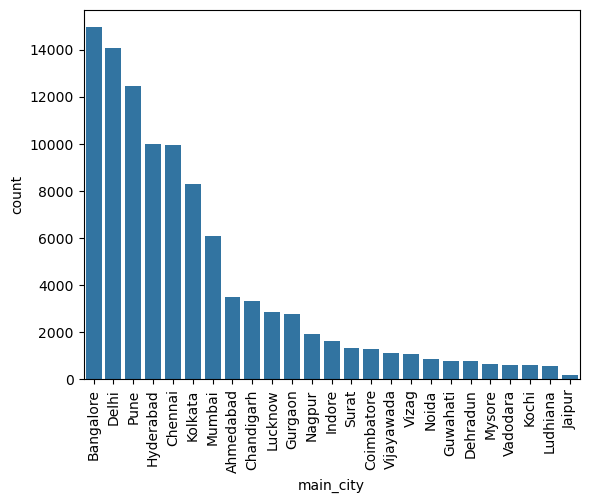

In [ ]:
#Let's vizualize the main_city column distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=df.main_city.value_counts().index,y=df.main_city.value_counts())
plt.xticks(rotation=90)
plt.show()

In [10]:
#Let's make a definition for the city column 
def splitting(x):
    parts = x.split(',')
    if len(parts)>1:
        return ','.join(parts[:-1])
    else:
        return x

In [11]:
df.city=df.city.apply(splitting)

In [17]:
df.city=df.city.str.replace('Aurangabad_bihar','Aurangabad')
df.city=df.city.str.upper()
df.main_city=df.main_city.str.upper()

In [25]:
df=df.dropna(subset=['name','rating','rating_count','cost','cuisine'])

In [36]:
#Let's handle the rating column
import warnings
warnings.filterwarnings('ignore')
df.rating=pd.to_numeric(df.rating,errors='coerce')

In [ ]:
df['rating']=df.groupby('city')['rating'].transform(lambda x:x.fillna(x.mean()))
df.head()

,name,city,rating,rating_count,cost,cuisine,main_city
0,AB FOODS POINT,ABOHAR,4.113333,Too Few Ratings,₹ 200,"Beverages,Pizzas",NaN
1,JANTA SWEET HOUSE,ABOHAR,4.400000,50+ ratings,₹ 200,"Sweets,Bakery",NaN
2,THEKA COFFEE DESI,ABOHAR,3.800000,100+ ratings,₹ 100,Beverages,NaN
3,SINGH HUT,ABOHAR,3.700000,20+ ratings,₹ 250,"Fast Food,Indian",NaN
4,GRILL MASTERS,ABOHAR,4.113333,Too Few Ratings,₹ 250,"Italian-American,Fast Food",NaN


In [59]:
df['rating']=df['rating'].round(1)
df.head()

,name,city,rating,rating_count,cost,cuisine,main_city
0,AB FOODS POINT,ABOHAR,4.1,Too Few Ratings,₹ 200,"Beverages,Pizzas",NaN
1,JANTA SWEET HOUSE,ABOHAR,4.4,50+ ratings,₹ 200,"Sweets,Bakery",NaN
2,THEKA COFFEE DESI,ABOHAR,3.8,100+ ratings,₹ 100,Beverages,NaN
3,SINGH HUT,ABOHAR,3.7,20+ ratings,₹ 250,"Fast Food,Indian",NaN
4,GRILL MASTERS,ABOHAR,4.1,Too Few Ratings,₹ 250,"Italian-American,Fast Food",NaN


In [60]:
def rating(x):
    if x>4.5:
        return 5.0
    elif x>4.0 and x<=4.5:
        return 4.5
    elif x>3.5 and x<=4.0:
        return 4.0
    elif x>3.0 and x<=3.5:
        return 3.5
    elif x>2.5 and x<=3.0:
        return 3.0
    elif x>2.0 and x<=2.5:
        return 2.5  
    elif x>1.5 and x<=2.0:
        return 2.0
    elif x>1.0 and x<=1.5:
        return 1.5
    elif x>0.5 and x<=1.0:
        return 1.0
    elif x>0.0 and x<=0.5:
        return 0.5
    else:
        return 0.0


In [71]:
df['rating']=df['rating'].apply(rating)
df

,name,city,rating,rating_count,cost,cuisine,main_city
0,AB FOODS POINT,ABOHAR,4.5,Too Few Ratings,₹ 200,"Beverages,Pizzas",NaN
1,JANTA SWEET HOUSE,ABOHAR,4.5,50+ ratings,₹ 200,"Sweets,Bakery",NaN
2,THEKA COFFEE DESI,ABOHAR,4.0,100+ ratings,₹ 100,Beverages,NaN
3,SINGH HUT,ABOHAR,4.0,20+ ratings,₹ 250,"Fast Food,Indian",NaN
4,GRILL MASTERS,ABOHAR,4.5,Too Few Ratings,₹ 250,"Italian-American,Fast Food",NaN
...,...,...,...,...,...,...,...
148501,THE FOOD DELIGHT,YAVATMAL,4.0,Too Few Ratings,₹ 200,"Fast Food,Snacks",NaN
148502,MAITRI FOODS & BEVERAGES,YAVATMAL,4.0,Too Few Ratings,₹ 300,Pizzas,NaN
148503,CAFE BELLA CIAO,YAVATMAL,4.0,Too Few Ratings,₹ 300,"Fast Food,Snacks",NaN
148504,GRILL ZILLA,YAVATMAL,4.0,Too Few Ratings,₹ 250,Continental,NaN


In [73]:
#Let's handle the rating_count column
df.rating_count.unique()

array(['Too Few Ratings', '50+ ratings', '100+ ratings', '20+ ratings',
       '500+ ratings', '1K+ ratings', '5K+ ratings', '10K+ ratings'],
      dtype=object)

In [74]:
def rating_count(x):
    if x=='Too Few Ratings':
        return None
    elif x=='20+ ratings':
        return 30
    elif x=='50+ ratings':
        return 80
    elif x=='100+ ratings':
        return 300
    elif x=='500+ ratings':
        return 800
    elif x=='1K+ ratings':
        return 3000
    elif x=='5K+ ratings':
        return 8000
    elif x=='10K+ ratings':
        return 15000
    else:
        return None

In [78]:
df['rating_count']=df['rating_count'].apply(rating_count)
df

,name,city,rating,rating_count,cost,cuisine,main_city
0,AB FOODS POINT,ABOHAR,4.5,NaN,₹ 200,"Beverages,Pizzas",NaN
1,JANTA SWEET HOUSE,ABOHAR,4.5,80.0,₹ 200,"Sweets,Bakery",NaN
2,THEKA COFFEE DESI,ABOHAR,4.0,300.0,₹ 100,Beverages,NaN
3,SINGH HUT,ABOHAR,4.0,30.0,₹ 250,"Fast Food,Indian",NaN
4,GRILL MASTERS,ABOHAR,4.5,NaN,₹ 250,"Italian-American,Fast Food",NaN
...,...,...,...,...,...,...,...
148501,THE FOOD DELIGHT,YAVATMAL,4.0,NaN,₹ 200,"Fast Food,Snacks",NaN
148502,MAITRI FOODS & BEVERAGES,YAVATMAL,4.0,NaN,₹ 300,Pizzas,NaN
148503,CAFE BELLA CIAO,YAVATMAL,4.0,NaN,₹ 300,"Fast Food,Snacks",NaN
148504,GRILL ZILLA,YAVATMAL,4.0,NaN,₹ 250,Continental,NaN


In [86]:
df['rating_count']=df.groupby('city')['rating_count'].transform(lambda x: x.fillna(x.mean()))

In [101]:
df['rating_count']=df['rating_count'].round(1)

In [113]:
df['rating_count']=df['rating_count'].fillna(df['rating_count'].mean())

In [115]:
df.rating_count=df.rating_count.astype('int64')

In [120]:
#Let's handle the cost column
df['cost']=df['cost'].str.replace('₹','').astype('int')
df.head()

,name,city,rating,rating_count,cost,cuisine,main_city
0,AB FOODS POINT,ABOHAR,4.5,91,200,"Beverages,Pizzas",NaN
1,JANTA SWEET HOUSE,ABOHAR,4.5,80,200,"Sweets,Bakery",NaN
2,THEKA COFFEE DESI,ABOHAR,4.0,300,100,Beverages,NaN
3,SINGH HUT,ABOHAR,4.0,30,250,"Fast Food,Indian",NaN
4,GRILL MASTERS,ABOHAR,4.5,91,250,"Italian-American,Fast Food",NaN


In [128]:
#Let's handle the cuisine column
df[['cuisine1','cuisine2']]=df.cuisine.str.split(',',expand=True)
df.head()

,name,city,rating,rating_count,cost,cuisine,main_city,cuisine1,cuisine2
0,AB FOODS POINT,ABOHAR,4.5,91,200,"Beverages,Pizzas",NaN,Beverages,Pizzas
1,JANTA SWEET HOUSE,ABOHAR,4.5,80,200,"Sweets,Bakery",NaN,Sweets,Bakery
2,THEKA COFFEE DESI,ABOHAR,4.0,300,100,Beverages,NaN,Beverages,None
3,SINGH HUT,ABOHAR,4.0,30,250,"Fast Food,Indian",NaN,Fast Food,Indian
4,GRILL MASTERS,ABOHAR,4.5,91,250,"Italian-American,Fast Food",NaN,Italian-American,Fast Food


In [ ]:
#Now we will drop the cuisine and cuisine2 columns because we don't need them
df.drop(columns=['cuisine','cuisine2'],inplace=True)

In [143]:
df.cuisine1.unique()

array(['Beverages', 'Sweets', 'Fast Food', 'Italian-American',
       'Continental', 'North Indian', 'Snacks', 'Indian', 'Juices',
       'Tandoor', 'Punjabi', 'Mughlai', 'Pizzas', 'Chinese', 'Ice Cream',
       'Chaat', 'Bakery', 'American', 'European', 'Biryani',
       'South Indian', 'Desserts', 'Street Food', 'Nepalese', 'Paan',
       'Healthy Food', 'Bengali', 'Thalis', 'Waffle', 'Arabian', 'Combo',
       'Tibetan', 'Burgers', 'Bihari', 'Italian', 'Salads', 'Kebabs',
       'Asian', 'Thai', 'North Eastern', 'Cafe', 'Pan-Asian', 'Lebanese',
       'Maharashtrian', 'Mexican', 'Pastas', 'Rajasthani', 'Gujarati',
       'Seafood', 'Japanese', 'Sushi', 'Middle Eastern', 'French',
       'Hyderabadi', 'Grill', 'SVANidhi Street Food Vendor', 'Afghani',
       'Oriental', 'Home Food', 'Barbecue', 'Korean', 'Kerala', 'Andhra',
       'British', 'Oriya', 'Portuguese', 'Lucknowi', 'Mangalorean',
       'Chettinad', 'Mediterranean', 'Naga', 'Turkish', 'Assamese',
       'Steakhouse', 'Coas

In [ ]:
Default, SVANidhi Street Food Vendor, 8:15 To 11:30 Pm, Bakery products, Free Delivery ! Limited Stocks!, Discount offer from Garden Cafe Express Kankurgachi, Special Discount from (Hotel Swagath),
Popular Brand Store,Grocery products

In [147]:
df.cuisine1=df.cuisine1.replace({'Default':None, 'SVANidhi Street Food Vendor':None, '8:15 To 11:30 Pm':None, 'Bakery products':"Bakery", 'Free Delivery ! Limited Stocks!':None, 'Discount offer from Garden Cafe Express Kankurgachi':None, 'Special Discount from (Hotel Swagath)':None, 'Popular Brand Store':None, 'Grocery products':'Grocery'})

<Axes: xlabel='cuisine1'>

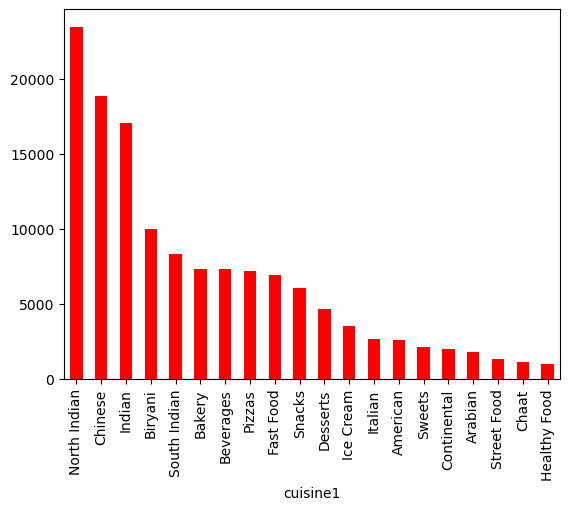

In [161]:
df.cuisine1.value_counts().nlargest(20).plot(kind='bar',color="red")

In [165]:
df['cuisine1']=df.groupby('city')['cuisine1'].transform(lambda x: x.fillna(x.mode()[0]))

In [173]:
df.cuisine1=df.cuisine1.str.upper()

In [190]:
#Let's us make NaN values to Other
df.main_city=df.main_city.fillna('OTHER')
df.head()

,name,city,rating,rating_count,cost,main_city,cuisine1
0,AB FOODS POINT,ABOHAR,4.5,91,200,OTHER,BEVERAGES
1,JANTA SWEET HOUSE,ABOHAR,4.5,80,200,OTHER,SWEETS
2,THEKA COFFEE DESI,ABOHAR,4.0,300,100,OTHER,BEVERAGES
3,SINGH HUT,ABOHAR,4.0,30,250,OTHER,FAST FOOD
4,GRILL MASTERS,ABOHAR,4.5,91,250,OTHER,ITALIAN-AMERICAN


In [ ]:
#Let's check any null values occurs in the dataset
df.isnull().sum()

name            0
city            0
rating          0
rating_count    0
cost            0
main_city       0
cuisine1        0
dtype: int64

In [192]:
# Now change the cuisine1 column to cuisine
df.rename(columns={'cuisine1':'cuisine'},inplace=True)
df.head()

,name,city,rating,rating_count,cost,main_city,cuisine
0,AB FOODS POINT,ABOHAR,4.5,91,200,OTHER,BEVERAGES
1,JANTA SWEET HOUSE,ABOHAR,4.5,80,200,OTHER,SWEETS
2,THEKA COFFEE DESI,ABOHAR,4.0,300,100,OTHER,BEVERAGES
3,SINGH HUT,ABOHAR,4.0,30,250,OTHER,FAST FOOD
4,GRILL MASTERS,ABOHAR,4.5,91,250,OTHER,ITALIAN-AMERICAN


In [194]:
# Let's save the cleaned data to a new csv file
df.to_csv('cleaned_data.csv',index=False)

# Data Preprocessing

In [22]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
le_name=LabelEncoder()
le_main_city=LabelEncoder()
ohe_city=OneHotEncoder()
ohe_cuisine=OneHotEncoder()
scaler_rating_count=MinMaxScaler()
scaler_cost=MinMaxScaler()

df['name']=le_name.fit_transform(df['name'])
df['main_city']=le_main_city.fit_transform(df['main_city'])
df['city']=ohe_city.fit_transform(df[['city']]).toarray()
df['cuisine']=ohe_cuisine.fit_transform(df[['cuisine']]).toarray()
df['rating_count']=scaler_rating_count.fit_transform(df[['rating_count']])
df['cost']=scaler_cost.fit_transform(df[['cost']])

In [24]:
# Let's save the pickle files
import pickle
with open('LabelEncoder_name.pkl','wb') as f:
    pickle.dump(le_name,f)
with open('LabelEncoder_main_city.pkl','wb') as f:
    pickle.dump(le_main_city,f)
with open('OneHotEncoder_city.pkl','wb') as f:
    pickle.dump(ohe_city,f)
with open('OneHotEncoder_cuisine.pkl','wb') as f:
    pickle.dump(ohe_cuisine,f)
with open('MinMaxScaler_rating_count.pkl','wb') as f:
    pickle.dump(scaler_rating_count,f)
with open('MinMaxScaler_cost.pkl','wb') as f:
    pickle.dump(scaler_cost,f)

In [210]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[['rating_count','cost']]=scaler.fit_transform(df[['rating_count','cost']])
df.head()

,name,city,rating,rating_count,cost,main_city,cuisine
0,1918,0.0,4.5,0.004075,0.000663,21,0.0
1,44526,0.0,4.5,0.003340,0.000663,21,0.0
2,98696,0.0,4.0,0.018036,0.000330,21,0.0
3,84375,0.0,4.0,0.000000,0.000829,21,0.0
4,34977,0.0,4.5,0.004075,0.000829,21,0.0


In [211]:
# Let's save the encoded data to a new csv file
df.to_csv('encoded_data1.csv',index=False)

In [215]:
#Let's save the pickle file for encoder and scaler
import pickle
with open('LabelEncoder.pkl','wb') as f:
    pickle.dump(label_encoder,f)
with open('OneHotEncoder.pkl','wb') as f:
    pickle.dump(one_hot_encoder,f)
with open('MinMaxScaler.pkl','wb') as f:
    pickle.dump(scaler,f)

In [216]:
df.shape

(148388, 7)

In [217]:
clean_data=pd.read_csv(r'D:\swiggy\cleaned_data.csv')
encode_data=pd.read_csv(r'D:\swiggy\encoded_data1.csv')

In [224]:
clean_data.shape[0]==encode_data.shape[0]

True

# temp use

In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd
import pickle
df=pd.read_csv(r'D:\swiggy\cleaned_data.csv')
label_encoder=LabelEncoder()
label_encoder.fit(df['main_city'])

with open('LabelEncoder_main_city.pkl','wb') as f:
    pickle.dump(label_encoder,f)

In [9]:
one_hot_encoder=OneHotEncoder()
one_hot_encoder.fit(df[['city']])
with open('OneHotEncoder_city.pkl','wb') as f:
    pickle.dump(one_hot_encoder,f)

In [16]:
df=pd.read_csv(r'cleaned_data.csv')

In [17]:
df

,name,city,rating,rating_count,cost,main_city,cuisine
0,AB FOODS POINT,ABOHAR,4.5,91,200,OTHER,BEVERAGES
1,JANTA SWEET HOUSE,ABOHAR,4.5,80,200,OTHER,SWEETS
2,THEKA COFFEE DESI,ABOHAR,4.0,300,100,OTHER,BEVERAGES
3,SINGH HUT,ABOHAR,4.0,30,250,OTHER,FAST FOOD
4,GRILL MASTERS,ABOHAR,4.5,91,250,OTHER,ITALIAN-AMERICAN
...,...,...,...,...,...,...,...
148383,THE FOOD DELIGHT,YAVATMAL,4.0,72,200,OTHER,FAST FOOD
148384,MAITRI FOODS & BEVERAGES,YAVATMAL,4.0,72,300,OTHER,PIZZAS
148385,CAFE BELLA CIAO,YAVATMAL,4.0,72,300,OTHER,FAST FOOD
148386,GRILL ZILLA,YAVATMAL,4.0,72,250,OTHER,CONTINENTAL
